# `03_boundaries_population`: Joining spatial units with population data (municipalities, provinces, H3 grid)

## Introduction

### Purpose

This notebook combines the spatial boundaries from `01_boundaries` with the population data from `02_population` to produce the joined spatial units used by the downstream pipeline. Each output table carries geometry (EPSG:4326), area in km², population, and population density (people per km²) for one spatial level: municipality, province, or H3 cell.

### Inputs

- `municipality_admin_areas_gdf`, `province_admin_areas_gdf`, `h3_cell_areas_gdf` from `01_boundaries`.
- `municipality_population`, `province_population`, `h3_population` from `02_population`.

### Outputs

- `municipalities`: 342 Dutch municipalities (2025) with geometry, area, population, urbanisation class, and density.
- `provinces`: 12 Dutch provinces with geometry, area, aggregated population, and density.
- `h3_cells`: 66,530 H3 cells at resolution 8, with geometry, area, population (zero-filled where the source omits a cell), and density.

### Key steps

For each spatial level, the boundaries table and the population table are merged on the shared key (`municipality_code`, `province_code`, or `h3_index`), the duplicate name or geometry column is dropped from one side to avoid a clash, the result is restored to a GeoDataFrame in EPSG:4326, and a `population_density` column is computed as `population / area_km2`. The H3 join uses a left join with a merge indicator, since the Kontur source dataset omits H3 cells with zero population entirely; unmatched cells are retained with `population = 0` and inspected in the diagnostic at the end. Per the thesis (Table 3, §3.4.6), the municipality table feeds the per-capita extent metric (length per 1,000 inhabitants), while the province and H3 tables enter only via the MAUP robustness check in stage 08.

### Dependencies on prior notebooks

- `01_boundaries.ipynb`: provides the three boundary GeoDataFrames.
- `02_population.ipynb`: provides the three population tables.

### Table of contents

1. [Environment setup](#1-environment-setup)
2. [Municipality](#2-municipality)
3. [Province](#3-province)
4. [H3 grid](#4-h3-grid)
   - 4.1 [Diagnostic: unmatched cells](#41-diagnostic-unmatched-cells)

---

## 1. Environment setup

### Libraries and extensions

In [23]:
from IPython.utils import io
from lonboard import viz
from lonboard.basemap import CartoStyle, MaplibreBasemap
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

### Loading shared variables

Execute the prior notebooks to bring the three boundary GeoDataFrames and the three population tables into the current session.

In [11]:
with io.capture_output() as captured:
    %run /home/vbo226/01_boundaries.ipynb
    %run /home/vbo226/02_population.ipynb

---

## 2. Municipality

`municipality_admin_areas_gdf` (boundaries plus area) and `municipality_population` (population plus the CBS urbanisation classification) are merged on `municipality_code`. Before the merge, `municipality_name` is dropped from the boundaries table because the population table already carries it, avoiding a duplicate column. After the merge the result is restored to a GeoDataFrame in EPSG:4326, and a `population_density` column (people per km²) is computed from `population / area_km2`. The resulting table is `municipalities`.

In [4]:
# Remove municipality_name from the admin areas table because it already exists in municipality_population (avoid duplicate columns in join)
municipality_admin_areas_gdf = municipality_admin_areas_gdf.drop(columns=["municipality_name"])

# Merge on municipality_code (shared key)
municipalities = municipality_population.merge(municipality_admin_areas_gdf, on='municipality_code')

# Restore GeoDataFrame (lost during join)
municipalities = gpd.GeoDataFrame(municipalities, geometry='geometry', crs='EPSG:4326')

# Calculate population density per municipality (number of people per km²) 
municipalities['population_density'] = municipalities['population'] / municipalities['area_km2']

In [7]:
municipalities

,province_code,province_name,municipality_code,municipality_name,population,code_degree_of_urbanisation,degree_of_urbanisation,geometry,area_km2,population_density
0,PV22,Drenthe,GM1680,Aa en Hunze,25935,5,Non-urbanized,"MULTIPOLYGON (((6.71477 52.86826, 6.71507 52.8...",278.866715,93.001418
1,PV27,Noord-Holland,GM0358,Aalsmeer,33250,4,Slightly urbanized,"MULTIPOLYGON (((4.72376 52.21657, 4.72382 52.2...",32.291045,1029.697227
2,PV25,Gelderland,GM0197,Aalten,27466,4,Slightly urbanized,"MULTIPOLYGON (((6.47259 51.85399, 6.47264 51.8...",97.061184,282.976147
3,PV21,Fryslân,GM0059,Achtkarspelen,28200,5,Non-urbanized,"MULTIPOLYGON (((6.12908 53.14862, 6.12918 53.1...",103.978322,271.210377
4,PV28,Zuid-Holland,GM0482,Alblasserdam,20242,2,Highly urbanized,"MULTIPOLYGON (((4.67483 51.8403, 4.67498 51.84...",10.061445,2011.838203
...,...,...,...,...,...,...,...,...,...,...
337,PV30,Noord-Brabant,GM0879,Zundert,22809,4,Slightly urbanized,"MULTIPOLYGON (((4.53452 51.42718, 4.53461 51.4...",121.216421,188.167575
338,PV25,Gelderland,GM0301,Zutphen,49028,2,Highly urbanized,"MULTIPOLYGON (((6.22149 52.08879, 6.22157 52.0...",42.940319,1141.770752
339,PV23,Overijssel,GM1896,Zwartewaterland,23507,4,Slightly urbanized,"MULTIPOLYGON (((6.14618 52.55501, 6.14622 52.5...",87.867641,267.527384
340,PV28,Zuid-Holland,GM0642,Zwijndrecht,44669,2,Highly urbanized,"MULTIPOLYGON (((4.65321 51.81346, 4.65609 51.8...",22.777619,1961.091697


## 3. Province

The province join mirrors the municipality logic: `province_admin_areas_gdf` and `province_population` are merged on `province_code` after dropping the duplicate `province_name` column from the boundaries table; the result is restored to a GeoDataFrame in EPSG:4326; and `population_density` is computed. The resulting table is `provinces`.

In [12]:
# Remove municipality_name from the admin areas table because it already exists in municipality_population (avoid duplicate columns in join)
province_admin_areas_gdf = province_admin_areas_gdf.drop(columns=["province_name"])

# Merge on province_code (shared key)
provinces = province_population.merge(province_admin_areas_gdf, on='province_code')

# Restore GeoDataFrame (lost during join)
provinces = gpd.GeoDataFrame(provinces, geometry='geometry', crs='EPSG:4326')

# Calculate population density per province (number of people per km²) 
provinces['population_density'] = provinces['population'] / provinces['area_km2']

In [6]:
provinces

,province_code,province_name,population,geometry,area_km2,population_density
0,PV20,Groningen,602833,"MULTIPOLYGON (((7.02685 52.91904, 7.027 52.919...",2954.841372,204.015351
1,PV21,Fryslân,664222,"MULTIPOLYGON (((5.89872 52.80864, 5.89877 52.8...",5753.318073,115.450248
2,PV22,Drenthe,506529,"MULTIPOLYGON (((6.51623 52.63015, 6.51614 52.6...",2680.423696,188.973482
3,PV23,Overijssel,1195789,"MULTIPOLYGON (((6.74938 52.11862, 6.74954 52.1...",3421.058822,349.537691
4,PV24,Flevoland,456395,"MULTIPOLYGON (((5.42666 52.25332, 5.45175 52.2...",2412.665944,189.166263
5,PV25,Gelderland,2161358,"MULTIPOLYGON (((5.76897 51.75238, 5.7693 51.75...",5137.052289,420.738953
6,PV26,Utrecht,1409144,"MULTIPOLYGON (((5.05181 51.85748, 5.05214 51.8...",1560.321591,903.111261
7,PV27,Noord-Holland,2992016,"MULTIPOLYGON (((5.04666 52.16598, 5.04668 52.1...",4092.396642,731.115838
8,PV28,Zuid-Holland,3863397,"MULTIPOLYGON (((4.42355 51.70947, 4.43438 51.7...",3308.231601,1167.813341
9,PV29,Zeeland,392969,"MULTIPOLYGON (((3.88819 51.20108, 3.8883 51.20...",2933.314483,133.967565


## 4. H3 grid

The H3 join differs from the previous two in three ways. First, `h3_population` carries its own geometry column (`geom`) and a Kontur-internal identifier (`fid`), both of which are dropped to avoid clashing with `h3_cell_areas_gdf`'s `geometry`. Second, the join is a left join, not an inner join: the Kontur source omits H3 cells with zero population entirely, so an inner join would silently drop those cells from the grid. The merge is run with `indicator=True` so unmatched cells can be isolated in the diagnostic below. Third, missing populations from the left join are filled with 0 before computing `population_density`. The resulting table is `h3_cells`.

In [15]:
# Remove geometry from the population table because it already exists in h3_cell_areas_gdf (avoid duplicate columns in join)
h3_population = h3_population.drop(columns=['fid', 'geom'])

# Merge on h3_index code (shared key)
h3_cells = h3_cell_areas_gdf.merge(h3_population, on='h3_index', how='left', indicator=True)

# Replace missing population values (from failed left join) with 0, i.e. no population is present in this cell
h3_cells["population"] = h3_cells["population"].fillna(0)

# Calculate population density per h3 cell (number of people per km²) 
h3_cells['population_density'] = h3_cells['population'] / h3_cells['area_km2']

In [16]:
h3_cells

,h3_index,geometry,area_km2,population,resolution,_merge,population_density
0,612936790103293951,"POLYGON ((5.40548 53.40924, 5.40383 53.405, 5....",0.606097,5.0,8.0,both,8.249507
1,613046224768991231,"POLYGON ((5.03422 51.5353, 5.03265 51.53095, 5...",0.629743,658.0,8.0,both,1044.870291
2,612936901329944575,"POLYGON ((6.1175 53.4035, 6.1158 53.39926, 6.1...",0.610194,0.0,NaN,left_only,0.000000
3,612936580008509439,"POLYGON ((5.70276 51.72289, 5.70113 51.71856, ...",0.631315,16.0,8.0,both,25.343943
4,612936888971427839,"POLYGON ((6.87114 52.96407, 6.86939 52.95981, ...",0.620623,1.0,8.0,both,1.611284
...,...,...,...,...,...,...,...
66525,612936582885801983,"POLYGON ((5.62648 51.90823, 5.62486 51.9039, 5...",0.628322,356.0,8.0,both,566.588301
66526,612936891848720383,"POLYGON ((6.79838 53.12068, 6.79663 53.11642, ...",0.617980,2.0,8.0,both,3.236351
66527,612936755905036287,"POLYGON ((4.67478 51.9506, 4.67323 51.94628, 4...",0.621899,0.0,NaN,left_only,0.000000
66528,612936867131686911,"POLYGON ((5.68548 53.06579, 5.68382 53.06153, ...",0.612564,84.0,8.0,both,137.128626


### 4.1 Diagnostic: unmatched cells

The H3 grid generated in `01_boundaries` at resolution 8 contains 66,530 cells covering the Dutch national territory. When joined with the Kontur population dataset, a 1:1 match would be expected if population values were available for every cell. The Kontur source, however, contains only 51,445 H3 cells with recorded population, leaving roughly 15,000 grid cells unmatched on the left.

Inspection of the unmatched cells (visualised below) shows them concentrated over water bodies, uninhabited land, and other non-residential regions. This is consistent with the structure of the Kontur dataset, which only includes H3 cells with population greater than zero and omits zero-population cells entirely. The left-join strategy above therefore retains those cells with `population = 0` (and `population_density = 0`), reflecting that their absence in the source indicates true zero rather than missing information.

The `_merge` column added by `indicator=True` is preserved in `h3_cells` so this diagnostic remains reproducible after the fact; downstream stages that do not need it can drop it explicitly.

In [17]:
# Keep rows that exist only in the left table (no match in h3_population)
failed_rows = h3_cells[h3_cells['_merge'] == 'left_only']

### 4.2 Visualization

#### Interactive

In [25]:
# Visualize unmatched rows
viz(failed_rows, map_kwargs={'basemap': MaplibreBasemap(style=CartoStyle.Positron)})

#### Static

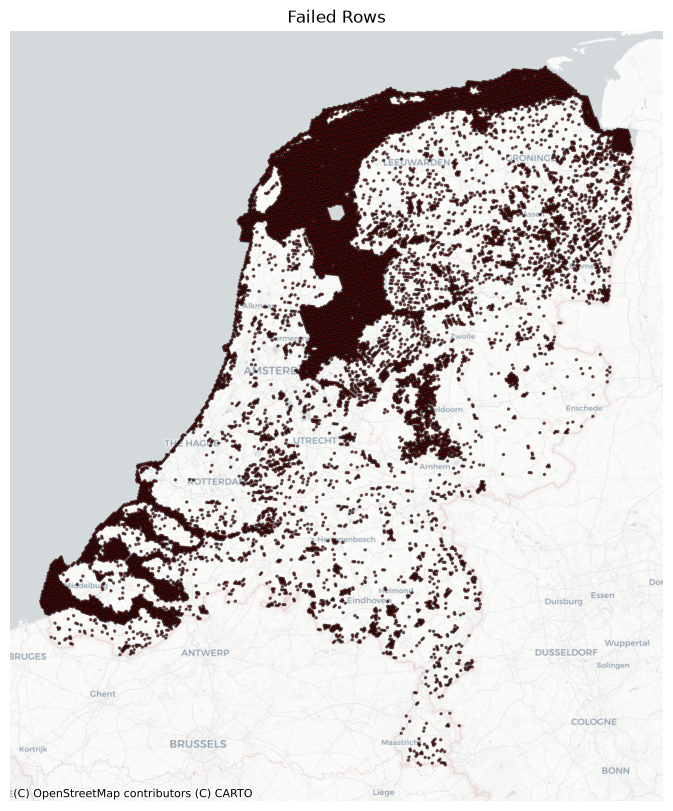

In [24]:
failed_rows = failed_rows.set_crs(epsg=4326)

failed_rows_3857 = failed_rows.to_crs(epsg=3857)

ax = failed_rows_3857.plot(
    figsize=(10, 10),
    color="red",
    alpha=0.6,
    edgecolor="black"
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Failed Rows")
ax.set_axis_off()

plt.show()